In [1]:
import numpy as np
import pandas as pd
import re
import warnings
warnings.filterwarnings("ignore")

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df = pd.read_excel('df_model_merged_output_최종.xlsx')
df.head(2)

,naver_article_id,writer_nickname,released_at,view_count,title,like_count,comment_count,comments,content,clean_content,...,clean_text,tokens,clean_text_joined,keyword_score,risk_score,comment_risk_ratio,risk_category_y,log_like_scaled,log_view_scaled,exposure_score
0,5327726,소담동아줌마,2025-02-26 20:39:00,3565,까르띠에 오픈런 후기,8,17,16.5가 있음 좋았을텐데요😭 나이들수록 손목도 굵어진다던데 나중엔 17로 하길 잘...,"\n <div class=""se-component se-...",2월 2일 공홈에서 로골 러브sm 16호 구매했고 2월 24일 발렉스로 받았는데요 ...,...,까르띠에 오픈런 후기 2월 2일 공홈에서 로골 러브sm 16호 구매했고 2월 24일...,"['까르띠에', '오픈', '런', '후기', '공', '홈', '로고', '러브'...",까르띠에 오픈 런 후기 공 홈 로고 러브 구매 발렉스 구매 착용감 판교 현대 게이트...,1,0.993111,0.470588,운영리스크,0.379891,0.565275,1.415755
1,5358331,오락가락아짐,2025-03-23 14:14:00,8104,러브 미듐 반품 고민,0,94,넘 이쁘시네용 !!ㅠㅠ 부럽.. 옐골이죠?|네..옐골 생각보다 너무 이뻐요~^^\n...,"\n <div class=""se-component se-...",아무래도 미듐 취소하고 오리지널로 사야할까봐요..남편이 깡마른 사람이나 이쁘겠다고 ...,...,러브 미듐 반품 고민 아무래도 미듐 취소하고 오리지널로 사야할까봐요 남편이 깡마른...,"['러브', '미듐', '반품', '고민', '미듐', '취소', '오리지널', '...",러브 미듐 반품 고민 미듐 취소 오리지널 남편 사람 학 기분,1,0.992734,0.180851,정책리스크,0.000000,0.690262,0.871113


In [3]:
df['released_at'].dtype

dtype('<M8[us]')

In [4]:
df['released_at'] = pd.to_datetime(df['released_at'], errors='coerce')
print(df['released_at'].dtype)

datetime64[us]


In [5]:
df.head(1)

,naver_article_id,writer_nickname,released_at,view_count,title,like_count,comment_count,comments,content,clean_content,...,clean_text,tokens,clean_text_joined,keyword_score,risk_score,comment_risk_ratio,risk_category_y,log_like_scaled,log_view_scaled,exposure_score
0,5327726,소담동아줌마,2025-02-26 20:39:00,3565,까르띠에 오픈런 후기,8,17,16.5가 있음 좋았을텐데요😭 나이들수록 손목도 굵어진다던데 나중엔 17로 하길 잘...,"\n <div class=""se-component se-...",2월 2일 공홈에서 로골 러브sm 16호 구매했고 2월 24일 발렉스로 받았는데요 ...,...,까르띠에 오픈런 후기 2월 2일 공홈에서 로골 러브sm 16호 구매했고 2월 24일...,"['까르띠에', '오픈', '런', '후기', '공', '홈', '로고', '러브'...",까르띠에 오픈 런 후기 공 홈 로고 러브 구매 발렉스 구매 착용감 판교 현대 게이트...,1,0.993111,0.470588,운영리스크,0.379891,0.565275,1.415755


In [6]:
df.isnull().sum()

naver_article_id            0
writer_nickname             0
released_at                 0
view_count                  0
title                       0
like_count                  0
comment_count               0
comments                   61
content                     0
clean_content               1
log_view_count              0
log_like_count              0
log_comment_count           0
text                        0
is_cartier                  0
is_product                  0
deleted_comment_count       0
deleted_comment_ratio       0
label                       0
pred_label                  0
pred_prob                   0
se_text                    20
risk_category_x             0
topic_name               1205
risk_prob                   0
sentiment_strength          0
clean_text                  0
tokens                      0
clean_text_joined           0
keyword_score               0
risk_score                  0
comment_risk_ratio          0
risk_category_y             0
log_like_s

In [7]:
print(df['topic_name'].isna().sum())
print(df['topic_name'].value_counts(dropna=False))

1205
topic_name
NaN             1205
셀러불친절_응대불량       103
웨이팅_오픈런           67
기스우려_내구성불안        64
재고부족_스트랩입고대기      44
가격인상불만            31
공홈재고부족            27
외관불량_하자인정거부       26
교환환불정책불만          22
Name: count, dtype: int64


In [16]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 사용 가능한 폰트 목록 중 Nanum 찾기
font_list = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
print(font_list)

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

['Nanum Gothic', 'Nanum Brush Script', 'Nanum Myeongjo']


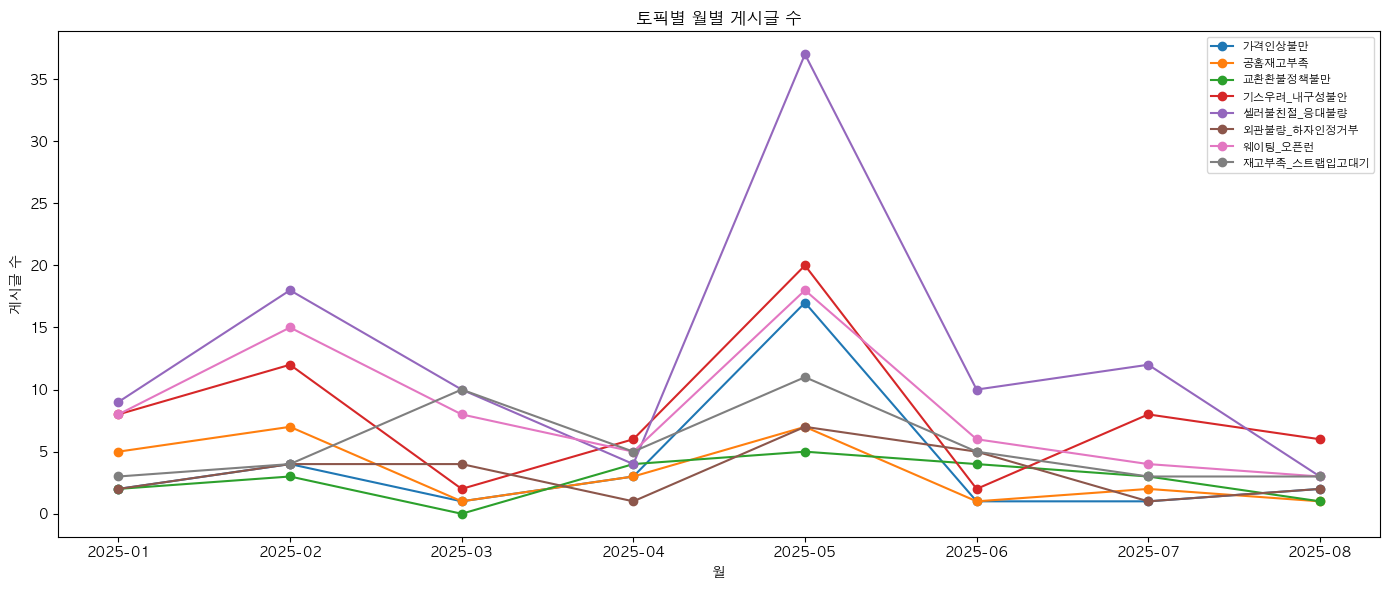

In [17]:
df['month'] = df['released_at'].dt.to_period('M')

timeline = df[df['topic_name'].notna()].groupby(['month', 'topic_name']).size().reset_index(name='count')

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'  # 이것만 바꾸면 돼요
plt.rcParams['axes.unicode_minus'] = False

pivot = timeline.pivot(index='month', columns='topic_name', values='count').fillna(0)
pivot.index = pivot.index.astype(str)

pivot.plot(figsize=(14, 6), marker='o')
plt.title('토픽별 월별 게시글 수')
plt.xlabel('월')
plt.ylabel('게시글 수')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()